In [25]:
# 0) Setup: Imports, Seeds, Paths, Device + Watchdog

from pathlib import Path
import random
import shutil
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

# Determinismus deaktivieren (Warnung vermeiden, Training stabil/schneller)
torch.use_deterministic_algorithms(False)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True  # zentral gesetzt

#Reproduzierbarkeit
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Optional: Für Performance
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True


# Device Logik: CUDA nur, wenn ein echter Kernel-Call klappt
def pick_device():
    if torch.cuda.is_available():
        try:
            _ = torch.randn(1, device="cuda")  # erzwingt einen echten Kernel-Launch
            return torch.device("cuda:0")
        except Exception as e:
            print("[WARN] CUDA erkannt, aber nicht nutzbar -> CPU-Fallback.")
            print("       Ursache:", str(e).splitlines()[0])
    return torch.device("cpu")


TORCH_DEVICE = pick_device()
CUDA_USABLE = (TORCH_DEVICE.type == "cuda")
YOLO_DEVICE = 0 if CUDA_USABLE else "cpu"  # Ultralytics: 0 = GPU0, sonst "cpu"

print("CUDA available (torch):", torch.cuda.is_available())
print("CUDA usable (kernel test):", CUDA_USABLE)
print("TORCH_DEVICE:", TORCH_DEVICE)
print("YOLO_DEVICE:", YOLO_DEVICE)
if CUDA_USABLE:
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))

# --- Pfade ---
DATA_DIR = Path("..") / "Data"

LABELED_DIR_OLD = DATA_DIR / "SAP Bilder sortiert"
LABELED_DIR_NEW = DATA_DIR / "SAP mit Pseudo Labels"
UNLABELED_DIR = DATA_DIR / "Rest Ungelabelt"

#ab hier arbeitet alles auf NEW
LABELED_DIR = LABELED_DIR_NEW

WORK_DIR = Path("..") / "Work"
WORK_DIR.mkdir(parents=True, exist_ok=True)

# NEW initialisieren (nur wenn NEW leer ist)
# Wenn NEW bereits gefüllt ist: lässt es in Ruhe.
INIT_NEW_FROM_OLD_IF_EMPTY = True
LABELED_DIR_NEW.mkdir(parents=True, exist_ok=True)
if INIT_NEW_FROM_OLD_IF_EMPTY and LABELED_DIR_OLD.exists() and not any(LABELED_DIR_NEW.iterdir()):
    shutil.copytree(LABELED_DIR_OLD, LABELED_DIR_NEW, dirs_exist_ok=True)
    print("[INIT] Kopiert OLD -> NEW (weil NEW leer war).")
    print("OLD:", LABELED_DIR_OLD)
    print("NEW:", LABELED_DIR_NEW)


# Hilfsfunktionen
def is_image(p: Path):
    return p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff"}


def list_images(folder: Path):
    return sorted([p for p in folder.rglob("*") if p.is_file() and is_image(p)])


# GPU Watchdog
MIN_FREE_MB_DEFAULT = 1500  # wenn weniger frei -> CPU-Fallback


def _bytes_to_mb(x):
    return float(x) / (1024 ** 2)


def cuda_mem_status():
    if not torch.cuda.is_available():
        return {"cuda": False}
    free_b, total_b = torch.cuda.mem_get_info()
    alloc_b = torch.cuda.memory_allocated()
    res_b = torch.cuda.memory_reserved()
    return {
        "cuda": True,
        "total_mb": _bytes_to_mb(total_b),
        "free_mb": _bytes_to_mb(free_b),
        "allocated_mb": _bytes_to_mb(alloc_b),
        "reserved_mb": _bytes_to_mb(res_b),
        "device": torch.cuda.get_device_name(0),
        "capability": torch.cuda.get_device_capability(0),
    }


def clear_jupyter_out_cache():
    # optional: kann helfen, wenn Out[] / _ große Objekte hält
    try:
        ip = get_ipython()  # noqa
        if "Out" in ip.user_ns:
            ip.user_ns["Out"].clear()
        for k in ["_", "__", "___"]:
            if k in ip.user_ns:
                ip.user_ns[k] = None
    except Exception:
        pass


def cuda_cleanup(clear_out_cache=False):
    if clear_out_cache:
        clear_jupyter_out_cache()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass
    gc.collect()


def ensure_best_device(min_free_mb=MIN_FREE_MB_DEFAULT, prefer_gpu=True, clear=True):

    #Wählt GPU wenn genug Speicher frei, sonst CPU. Macht optional Cleanup.
    #Rückgabe: (device, use_cuda_bool)

    if clear:
        cuda_cleanup(clear_out_cache=False)

    if prefer_gpu and torch.cuda.is_available():
        free_b, _total_b = torch.cuda.mem_get_info()
        free_mb = free_b / (1024 ** 2)
        if free_mb >= float(min_free_mb):
            return torch.device("cuda:0"), True
    return torch.device("cpu"), False


def watchdog(min_free_mb=MIN_FREE_MB_DEFAULT, auto_set=True, clear=True, clear_out_cache=False):

    #Zeigt Status, macht ein Cleanup und setzt optional TORCH_DEVICE/CUDA_USABLE/YOLO_DEVICE passend.

    before = cuda_mem_status()
    print("---- CUDA status (before) ----")
    print(before)

    if clear:
        cuda_cleanup(clear_out_cache=clear_out_cache)
    after = cuda_mem_status()
    print("---- CUDA status (after cleanup) ----")
    print(after)

    if auto_set:
        global TORCH_DEVICE, CUDA_USABLE, YOLO_DEVICE
        if after.get("cuda", False) and after["free_mb"] >= float(min_free_mb):
            TORCH_DEVICE = torch.device("cuda:0")
            CUDA_USABLE = True
            YOLO_DEVICE = 0
            print(f"[WATCHDOG] Using GPU (free {after['free_mb']:.0f} MB >= {min_free_mb} MB).")
        else:
            TORCH_DEVICE = torch.device("cpu")
            CUDA_USABLE = False
            YOLO_DEVICE = "cpu"
            if after.get("cuda", False):
                print(f"[WATCHDOG] GPU too full (free {after['free_mb']:.0f} MB < {min_free_mb} MB) -> CPU fallback.")
            else:
                print("[WATCHDOG] CUDA not available -> CPU fallback.")

    return after

CUDA available (torch): True
CUDA usable (kernel test): True
TORCH_DEVICE: cuda:0
YOLO_DEVICE: 0
GPU: NVIDIA GeForce RTX 5080
Capability: (12, 0)


,class,count
10,Excel,75
11,Query,72
4,Data Flow Object,44
9,DTP,42
8,Datenvorschau,41
12,Transformationen,39
2,BW4Cockpit (Stammdaten),38
0,ABAP Dictionary,33
6,Data Source,28
3,Composite Provider,17


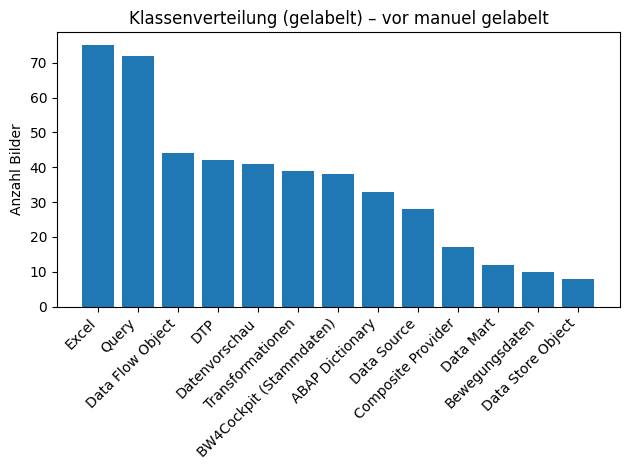

In [26]:
# 1) Statistik der Klassen verteilung für SAP Bilder sortiert
rows = []
for cls_dir in LABELED_DIR_OLD.iterdir():
    if not cls_dir.is_dir():
        continue
    n = sum(1 for f in cls_dir.iterdir() if f.is_file() and is_image(f))
    rows.append({"class": cls_dir.name, "count": n})

df_old = pd.DataFrame(rows).sort_values("count", ascending=False)
display(df_old)

plt.figure()
plt.bar(df_old["class"], df_old["count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Anzahl Bilder")
plt.title("Klassenverteilung (gelabelt) – vor manuel gelabelt")
plt.tight_layout()
plt.show()

In [27]:
# 2) Plan berechnen – (nur Analyse/Plan anzeigen)
counts_old = {}
for cls_dir in LABELED_DIR_OLD.iterdir():
    if cls_dir.is_dir():
        counts_old[cls_dir.name] = sum(1 for f in cls_dir.iterdir() if f.is_file() and is_image(f))

s_old = pd.Series(counts_old).sort_values(ascending=False)
print("Counts OLD:\n", s_old)

cap_old = 75
target_old = 50

downsample_old = (s_old - cap_old).clip(lower=0).astype(int)   # nur >75
topup_old      = (target_old - s_old).clip(lower=0).astype(int)

print("\n[OLD] Downsample (remove if > cap):\n", downsample_old[downsample_old > 0])
print("\n[OLD] Underrepresented vs target:\n", topup_old[topup_old > 0])
print("\n[OLD] Total missing to reach target:", int(topup_old.sum()))

Counts OLD:
 Excel                      75
Query                      72
Data Flow Object           44
DTP                        42
Datenvorschau              41
Transformationen           39
BW4Cockpit (Stammdaten)    38
ABAP Dictionary            33
Data Source                28
Composite Provider         17
Data Mart                  12
Bewegungsdaten             10
Data Store Object           8
dtype: int64

[OLD] Downsample (remove if > cap):
 Series([], dtype: int32)

[OLD] Underrepresented vs target:
 Data Flow Object            6
DTP                         8
Datenvorschau               9
Transformationen           11
BW4Cockpit (Stammdaten)    12
ABAP Dictionary            17
Data Source                22
Composite Provider         33
Data Mart                  38
Bewegungsdaten             40
Data Store Object          42
dtype: int32

[OLD] Total missing to reach target: 238


In [28]:
"""
# 3) Optional: Downsample wirklich durchführen (Bilder wegbewegen) wird nicht benötigt da Bilder manuelle eingefügt wurden
DO_DOWNSAMPLE = True  #  auf True, wenn Bilder verschieben werden sollen

REDUCED_DIR = WORK_DIR / "reduced"
REDUCED_DIR.mkdir(parents=True, exist_ok=True)

rng = random.Random(seed)

def move_random_images(cls_name: str, n_remove: int):
    src_dir = LABELED_DIR / cls_name
    if not src_dir.exists():
        print(f"[WARN] Klasse nicht gefunden: {cls_name}")
        return 0

    imgs = [p for p in src_dir.iterdir() if p.is_file() and is_image(p)]
    if n_remove <= 0:
        return 0

    rng.shuffle(imgs)
    to_move = imgs[:min(n_remove, len(imgs))]

    dst_dir = REDUCED_DIR / cls_name
    dst_dir.mkdir(parents=True, exist_ok=True)

    for p in to_move:
        shutil.move(str(p), str(dst_dir / p.name))

    return len(to_move)

if DO_DOWNSAMPLE:
    removed_total = 0
    for cls_name, n_remove in downsample.items():
        n_remove = int(n_remove)
        if n_remove > 0:
            moved = move_random_images(cls_name, n_remove)
            removed_total += moved
            print(f"Reduced {cls_name}: moved {moved} images -> {REDUCED_DIR / cls_name}")
    print("Total moved:", removed_total)
else:
    print("DO_DOWNSAMPLE=False -> nichts verschoben.")
"""

'\n# 3) Optional: Downsample wirklich durchführen (Bilder wegbewegen) wird nicht benötigt da Bilder manuelle eingefügt wurden\nDO_DOWNSAMPLE = True  #  auf True, wenn Bilder verschieben werden sollen\n\nREDUCED_DIR = WORK_DIR / "reduced"\nREDUCED_DIR.mkdir(parents=True, exist_ok=True)\n\nrng = random.Random(seed)\n\ndef move_random_images(cls_name: str, n_remove: int):\n    src_dir = LABELED_DIR / cls_name\n    if not src_dir.exists():\n        print(f"[WARN] Klasse nicht gefunden: {cls_name}")\n        return 0\n\n    imgs = [p for p in src_dir.iterdir() if p.is_file() and is_image(p)]\n    if n_remove <= 0:\n        return 0\n\n    rng.shuffle(imgs)\n    to_move = imgs[:min(n_remove, len(imgs))]\n\n    dst_dir = REDUCED_DIR / cls_name\n    dst_dir.mkdir(parents=True, exist_ok=True)\n\n    for p in to_move:\n        shutil.move(str(p), str(dst_dir / p.name))\n\n    return len(to_move)\n\nif DO_DOWNSAMPLE:\n    removed_total = 0\n    for cls_name, n_remove in downsample.items():\n     

,class,count
10,Excel,75
11,Query,72
4,Data Flow Object,59
0,ABAP Dictionary,50
2,BW4Cockpit (Stammdaten),50
6,Data Source,50
8,Datenvorschau,50
9,DTP,50
12,Transformationen,50
7,Data Store Object,49


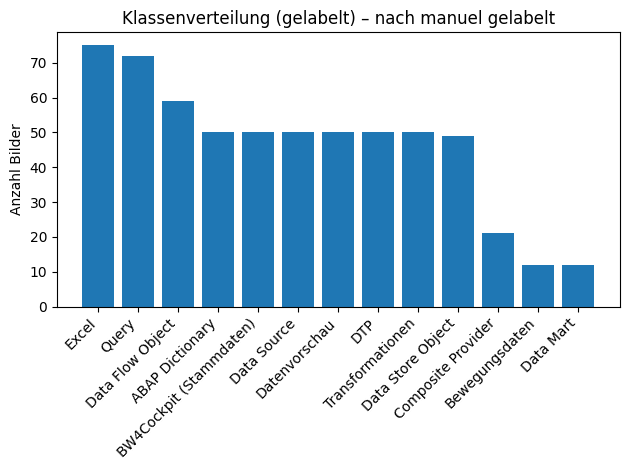

In [29]:
# 4) Kontrolle: Klassenverteilung nach dem Auffüllen der Klassen
rows = []
for cls_dir in LABELED_DIR.iterdir():
    if not cls_dir.is_dir():
        continue
    n = sum(1 for f in cls_dir.iterdir() if f.is_file() and is_image(f))
    rows.append({"class": cls_dir.name, "count": n})

df2 = pd.DataFrame(rows).sort_values("count", ascending=False)
display(df2)

plt.figure()
plt.bar(df2["class"], df2["count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Anzahl Bilder")
plt.title("Klassenverteilung (gelabelt) – nach manuel gelabelt")
plt.tight_layout()
plt.show()

In [30]:
# 5) Train/Val Split als Ordnerstruktur, mit ImageFolder kompatibel
rng = random.Random(seed)

SPLIT_DIR = WORK_DIR / "datasets" / "base_split"
TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR   = SPLIT_DIR / "val"

if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)
TRAIN_DIR.mkdir(parents=True, exist_ok=True)
VAL_DIR.mkdir(parents=True, exist_ok=True)

val_ratio = 0.2

def safe_copy(src: Path, dst: Path):

    #Kopiert Datei kollisionssicher.
    #Falls dst bereits existiert (doppelter Dateiname), wird ein eindeutiger Name erzeugt,
    #damit keine Samples verloren gehen.

    dst.parent.mkdir(parents=True, exist_ok=True)

    if dst.exists():
        # eindeutigen Namen erzeugen (Dateigröße + Zufallszahl aus rng)
        suffix = f"__dup{src.stat().st_size}__{rng.randint(0, 10**9)}"
        dst = dst.with_name(f"{dst.stem}{suffix}{dst.suffix}")

    shutil.copy2(src, dst)

for cls_dir in LABELED_DIR.iterdir():
    if not cls_dir.is_dir():
        continue
    cls = cls_dir.name
    imgs = [p for p in cls_dir.iterdir() if p.is_file() and is_image(p)]
    rng.shuffle(imgs)
    if len(imgs) == 0:
        continue

    n_val = max(1, int(len(imgs) * val_ratio))
    val_imgs = imgs[:n_val]
    train_imgs = imgs[n_val:]

    for p in train_imgs:
        safe_copy(p, TRAIN_DIR / cls / p.name)
    for p in val_imgs:
        safe_copy(p, VAL_DIR / cls / p.name)

print("Split erstellt:", SPLIT_DIR)

Split erstellt: ..\Work\datasets\base_split


YOLO baseline classes (ImageFolder order): ['ABAP Dictionary', 'BW4Cockpit (Stammdaten)', 'Bewegungsdaten', 'Composite Provider', 'DTP', 'Data Flow Object', 'Data Mart', 'Data Source', 'Data Store Object', 'Datenvorschau', 'Excel', 'Query', 'Transformationen']
n_classes: 13
---- CUDA status (before) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14247.0, 'allocated_mb': 483.78369140625, 'reserved_mb': 620.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
---- CUDA status (after cleanup) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14247.0, 'allocated_mb': 483.78369140625, 'reserved_mb': 620.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
[WATCHDOG] Using GPU (free 14247 MB >= 2000 MB).
VAL samples for YOLO baseline: 117
YOLO baseline (pretrained backbone + random head) acc: 0.0855 | device: cuda:0
                         precision    recall  f1-score   support

        ABAP Dictionary       0.00      0.00      0.00        10
BW4Cockpit (St

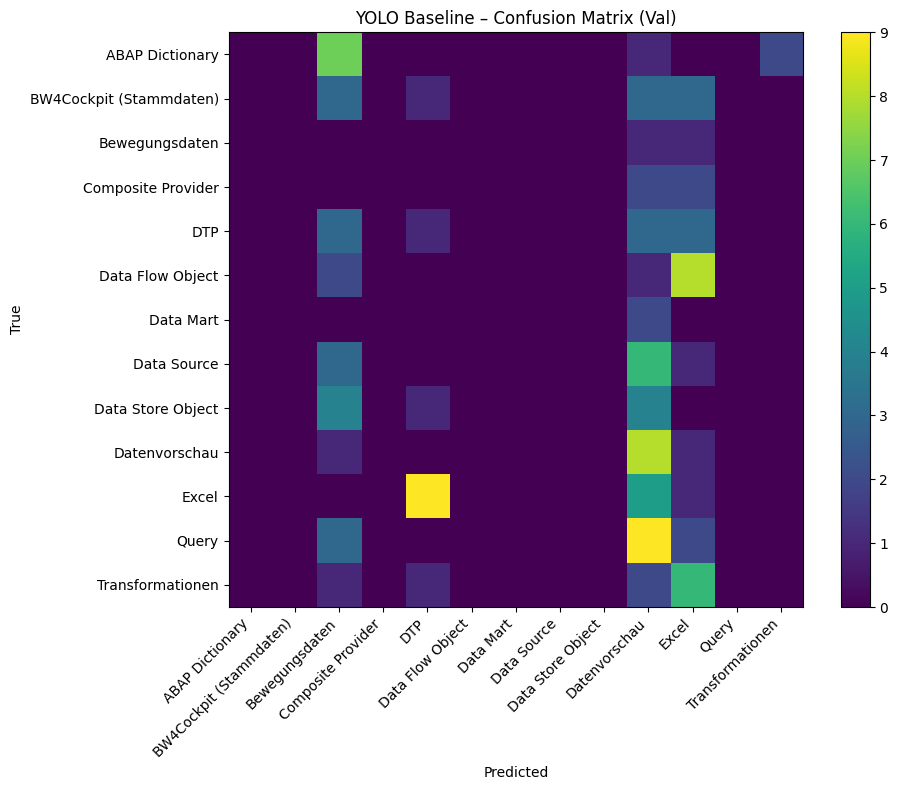

In [31]:
# 5.5 YOLO BASELINE (ohne Training)
# - Klassenreihenfolge wird via torchvision.datasets.ImageFolder(TRAIN_DIR) bestimmt
# - Val-Samples werden via ImageFolder(VAL_DIR) gelesen und auf Train-Klassen gemappt
# - Modell: yolov8n-cls.pt (pretrained Backbone) + neuer zufälliger Head (n_classes)
# - Evaluation auf VAL (ohne Training) => Baseline-Metriken + Save in RESULTS

import numpy as np
import torch
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn as nn

from ultralytics import YOLO
from torchvision import datasets  #ImageFolder für konsistente class order

# Falls RESULTS/save_results noch nicht existieren
if "RESULTS" not in globals():
    RESULTS = {}

def save_results(name, y_true, y_pred):
    RESULTS[name] = {
        "y_true": np.array(y_true, copy=True),
        "y_pred": np.array(y_pred, copy=True),
    }


# 1) Klassenreihenfolge exakt so wie ImageFolder sie später auch liefert
train_tmp = datasets.ImageFolder(str(TRAIN_DIR))   # liest nur Struktur + Files
class_names = train_tmp.classes
n_classes = len(class_names)
train_class_to_idx = {c: i for i, c in enumerate(class_names)}

print("YOLO baseline classes (ImageFolder order):", class_names)
print("n_classes:", n_classes)


# 2) YOLO Head ersetzen (random Head auf n_classes)
def adapt_yolo_classify_head(yolo_obj, class_names):
    #Ersetzt den finalen Classify-Linear-Layer auf len(class_names) und init zufällig.
    n_classes_local = len(class_names)

    head = None
    for m in yolo_obj.model.modules():
        if m.__class__.__name__.lower() == "classify":
            head = m
            break
    if head is None:
        raise RuntimeError("Konnte YOLO 'Classify' Head nicht finden. Ultralytics-Version prüfen.")

    if not hasattr(head, "linear") or not isinstance(head.linear, nn.Linear):
        raise RuntimeError("Classify-Head hat keinen erwarteten 'linear' Layer. Ultralytics-Version prüfen.")

    in_f = head.linear.in_features
    head.linear = nn.Linear(in_f, n_classes_local)
    nn.init.normal_(head.linear.weight, 0.0, 0.01)
    nn.init.zeros_(head.linear.bias)

    names_dict = {i: n for i, n in enumerate(class_names)}
    if hasattr(yolo_obj, "model") and hasattr(yolo_obj.model, "names"):
        try:
            yolo_obj.model.names = names_dict
        except Exception:
            pass
    if hasattr(yolo_obj, "model") and hasattr(yolo_obj.model, "args") and isinstance(yolo_obj.model.args, dict):
        yolo_obj.model.args["nc"] = n_classes_local

    return yolo_obj

def get_yolo_cls_transform(imgsz=224):
    try:
        from ultralytics.data.augment import classify_transforms
        return classify_transforms(imgsz)
    except Exception:
        import torchvision.transforms as T
        mean_ = (0.485, 0.456, 0.406)
        std_  = (0.229, 0.224, 0.225)
        return T.Compose([
            T.Resize((imgsz, imgsz)),
            T.ToTensor(),
            T.Normalize(mean=mean_, std=std_),
        ])

def yolo_logits(yolo_obj, x):
    m = yolo_obj.model
    core = getattr(m, "model", None)
    out = core(x) if core is not None else m(x)
    if isinstance(out, (tuple, list)):
        out = out[0]
    return out


# 3) Baseline-Modell bauen
watchdog(min_free_mb=2000, auto_set=True, clear=True)

yolo_baseline = YOLO("yolov8n-cls.pt")
yolo_baseline = adapt_yolo_classify_head(yolo_baseline, class_names)


# 4) VAL-Samples via ImageFolder lesen und Labels auf Train-Class-Index mappen
val_tmp = datasets.ImageFolder(str(VAL_DIR))
val_paths_raw = [Path(p) for p, _ in val_tmp.samples]
val_y_raw = [y for _, y in val_tmp.samples]
val_classes_raw = val_tmp.classes  # Reihenfolge wie VAL_DIR

# Mapping: val-class-name -> train-index
missing_in_train = []
y_true = np.empty(len(val_paths_raw), dtype=int)
valid_mask = np.ones(len(val_paths_raw), dtype=bool)

for i, yv in enumerate(val_y_raw):
    cname = val_classes_raw[int(yv)]
    if cname not in train_class_to_idx:
        missing_in_train.append(cname)
        valid_mask[i] = False
    else:
        y_true[i] = train_class_to_idx[cname]

if not np.all(valid_mask):
    #falls VAL_DIR Klassen hat, die TRAIN_DIR nicht hat
    kept = int(valid_mask.sum())
    print(f"[WARN] VAL enthält Klassen, die nicht in TRAIN sind. Dropping {len(valid_mask)-kept} Samples.")
    print("[WARN] Missing classes:", sorted(set(missing_in_train)))
    val_paths = [p for p, keep in zip(val_paths_raw, valid_mask) if keep]
    y_true = y_true[valid_mask]
else:
    val_paths = val_paths_raw

print("VAL samples for YOLO baseline:", len(val_paths))


# 5) Inferenz
tf_yolo = get_yolo_cls_transform(224)

dev = TORCH_DEVICE
use_amp = (dev.type == "cuda")
yolo_baseline.model.to(dev).eval()

BATCH = 16
y_pred = np.empty(len(val_paths), dtype=int)

with torch.inference_mode():
    for start in range(0, len(val_paths), BATCH):
        chunk = val_paths[start:start + BATCH]
        imgs = [tf_yolo(Image.open(p).convert("RGB")) for p in chunk]
        x = torch.stack(imgs, dim=0).to(dev, non_blocking=use_amp)

        if use_amp:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                logits = yolo_logits(yolo_baseline, x)
        else:
            logits = yolo_logits(yolo_baseline, x)

        top1 = logits.argmax(dim=1).detach().cpu().numpy().astype(int)
        y_pred[start:start + len(chunk)] = top1


# 6) Report + Confusion Matrix + Save
acc = float((y_true == y_pred).mean())
print(f"YOLO baseline (pretrained backbone + random head) acc: {acc:.4f} | device: {dev}")

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("YOLO Baseline – Confusion Matrix (Val)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()

save_results("YOLOv8n-cls baseline (random head)", y_true, y_pred)

cuda_cleanup()

In [32]:
# 6) YOLO Training (GPU wenn möglich; sonst CPU) + best.pt aus DEFINIERTEM Run laden
from ultralytics import YOLO
from pathlib import Path

watchdog(min_free_mb=2000, auto_set=True, clear=True)


# Train starten (Run-Pfad fixieren)
YOLO_PROJECT = WORK_DIR / "yolo_runs"
YOLO_RUNNAME = "sap_cls"

yolo_model = YOLO("yolov8n-cls.pt")
yolo_model.train(
    data=str(SPLIT_DIR),
    imgsz=224,
    epochs=100,
    batch=32,
    workers=2,
    device=YOLO_DEVICE,
    verbose=True,
    project=str(YOLO_PROJECT),
    name=YOLO_RUNNAME,
    exist_ok=True
)

# Optional: Ultralytics-VAL (kann je nach Setup fehlschlagen)
DO_YOLO_VAL_AFTER_TRAIN = True
if DO_YOLO_VAL_AFTER_TRAIN:
    try:
        m2 = yolo_model.val(data=str(SPLIT_DIR), device=YOLO_DEVICE)
        print("YOLO val() output:", m2)
    except Exception as e:
        print("[WARN] yolo_model.val() übersprungen/fehlgeschlagen:", str(e).splitlines()[0])


# best.pt sicher aus dem Run-Ordner laden
def _find_latest_pt(root: Path, filename: str):
    root = Path(root)
    if not root.exists():
        return None
    pts = sorted(root.rglob(filename), key=lambda p: p.stat().st_mtime, reverse=True)
    return pts[0] if pts else None

# 1) Primär: exakter Run-Pfad aus dem Ultralytics-Trainer
save_dir = None
trainer = getattr(yolo_model, "trainer", None)
if trainer is not None and hasattr(trainer, "save_dir"):
    try:
        save_dir = Path(trainer.save_dir)
    except Exception:
        save_dir = None

# 2) Typische Kandidaten
candidates = []
if save_dir is not None:
    candidates.append(save_dir)

# häufiges Layout: project/classify/name
candidates.append(YOLO_PROJECT / "classify" / YOLO_RUNNAME)
# alternatives Layout: project/name
candidates.append(YOLO_PROJECT / YOLO_RUNNAME)
# Default runs/classify
candidates.append(Path("runs") / "classify")

BEST_PT = None
LAST_PT = None

# 3) Direkt nach weights/best.pt / weights/last.pt suchen
for d in candidates:
    d = Path(d)
    if not d.exists():
        continue
    bp = d / "weights" / "best.pt"
    lp = d / "weights" / "last.pt"
    if bp.exists():
        BEST_PT = bp
        break
    if lp.exists() and LAST_PT is None:
        LAST_PT = lp

# 4) Rekursiver Fallback
if BEST_PT is None:
    search_roots = []
    if save_dir is not None:
        search_roots.append(save_dir)
    search_roots.append(YOLO_PROJECT)
    search_roots.append(Path("runs") / "classify")

    for root in search_roots:
        found = _find_latest_pt(root, "best.pt")
        if found is not None:
            BEST_PT = found
            break

# 5) Fallback auf last.pt + Debug wenn nichts da ist
if BEST_PT is None:
    if LAST_PT is None:
        LAST_PT = _find_latest_pt(YOLO_PROJECT, "last.pt") or _find_latest_pt(Path("runs") / "classify", "last.pt")

    if LAST_PT is None:
        print("[DEBUG] YOLO_PROJECT:", YOLO_PROJECT, "| exists:", YOLO_PROJECT.exists())
        if YOLO_PROJECT.exists():
            print("[DEBUG] Subdirs YOLO_PROJECT:", [p.name for p in YOLO_PROJECT.iterdir() if p.is_dir()])
        rc = Path("runs") / "classify"
        print("[DEBUG] runs/classify:", rc, "| exists:", rc.exists())
        if rc.exists():
            print("[DEBUG] Subdirs runs/classify:", [p.name for p in rc.iterdir() if p.is_dir()])

        raise FileNotFoundError(
            "Kein best.pt/last.pt gefunden. "
            "Entweder ist das Training nicht fertig durchgelaufen oder der Output-Pfad ist anders. "
            "Siehe DEBUG-Ausgaben oben."
        )

    print(f"[WARN] best.pt nicht gefunden -> nehme last.pt: {LAST_PT}")
    BEST_PT = LAST_PT

print("Using YOLO weights:", BEST_PT)
yolo_best = YOLO(str(BEST_PT))

cuda_cleanup()

---- CUDA status (before) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14247.0, 'allocated_mb': 483.78369140625, 'reserved_mb': 620.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
---- CUDA status (after cleanup) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14247.0, 'allocated_mb': 483.78369140625, 'reserved_mb': 620.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
[WATCHDOG] Using GPU (free 14247 MB >= 2000 MB).
New https://pypi.org/project/ultralytics/8.4.4 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.252  Python-3.12.10 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5080, 16303MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\Work\datasets\base_split, degrees=0.0, deterministic=True, dev

In [33]:
# 7) ResNet Setup (DataLoaders, Transforms, auto GPU/CPU)
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

if "RESULTS" not in globals():
    RESULTS = {}

def save_results(name, y_true, y_pred):
    RESULTS[name] = {
        "y_true": np.array(y_true, copy=True),
        "y_pred": np.array(y_pred, copy=True),
    }

NUM_WORKERS = 0
BATCH_TRAIN = 32
BATCH_VAL   = 32

weights = models.ResNet18_Weights.IMAGENET1K_V1
val_tf = weights.transforms()
mean = weights.transforms().mean
std  = weights.transforms().std

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

train_ds = datasets.ImageFolder(str(TRAIN_DIR), transform=train_tf)
val_ds   = datasets.ImageFolder(str(VAL_DIR), transform=val_tf)

class_names = train_ds.classes
n_classes = len(class_names)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_TRAIN, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=CUDA_USABLE
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_VAL, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=CUDA_USABLE
)

print("Klassen (ImageFolder-Reihenfolge):", class_names)
print("n_classes:", n_classes)

Klassen (ImageFolder-Reihenfolge): ['ABAP Dictionary', 'BW4Cockpit (Stammdaten)', 'Bewegungsdaten', 'Composite Provider', 'DTP', 'Data Flow Object', 'Data Mart', 'Data Source', 'Data Store Object', 'Datenvorschau', 'Excel', 'Query', 'Transformationen']
n_classes: 13


In [34]:
# 8) ResNet Eval (auto GPU->CPU) + Baselines
def eval_model_auto(model, loader, min_free_mb=1200):
    device, use_cuda = ensure_best_device(min_free_mb=min_free_mb, prefer_gpu=True, clear=True)
    model = model.to(device).eval()
    y_true, y_pred = [], []
    with torch.inference_mode():
        for x, y in loader:
            x = x.to(device, non_blocking=use_cuda)
            logits = model(x)
            pred = logits.argmax(dim=1).detach().cpu().numpy()
            y_true.extend(y.numpy())
            y_pred.extend(pred)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = float((y_true == y_pred).mean())
    return y_true, y_pred, acc, device

# Baseline A: random
resnet_untrained = models.resnet18(weights=None)
resnet_untrained.fc = nn.Linear(resnet_untrained.fc.in_features, n_classes)

y_true, y_pred, acc, dev = eval_model_auto(resnet_untrained, val_loader)
print("RESNET untrained baseline acc:", acc, "| device:", dev)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
save_results("ResNet18 random", y_true, y_pred)

# Baseline B: pretrained backbone, neuer Kopf (untrainiert)
resnet_pre = models.resnet18(weights=weights)
resnet_pre.fc = nn.Linear(resnet_pre.fc.in_features, n_classes)

y_true, y_pred, acc, dev = eval_model_auto(resnet_pre, val_loader)
print("RESNET pretrained (no finetune) acc:", acc, "| device:", dev)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
save_results("ResNet18 pretrained (no finetune)", y_true, y_pred)

RESNET untrained baseline acc: 0.042735042735042736 | device: cuda:0
                         precision    recall  f1-score   support

        ABAP Dictionary       0.00      0.00      0.00        10
BW4Cockpit (Stammdaten)       0.00      0.00      0.00        10
         Bewegungsdaten       0.00      0.00      0.00         2
     Composite Provider       0.03      0.75      0.06         4
                    DTP       0.00      0.00      0.00        10
       Data Flow Object       0.00      0.00      0.00        11
              Data Mart       0.00      0.00      0.00         2
            Data Source       0.00      0.00      0.00        10
      Data Store Object       0.00      0.00      0.00         9
          Datenvorschau       0.13      0.20      0.16        10
                  Excel       0.00      0.00      0.00        15
                  Query       0.00      0.00      0.00        14
       Transformationen       0.00      0.00      0.00        10

               accu

In [35]:
# 9) ResNet Fine-Tuning (AMP wenn CUDA; ansonsten CPU)
CKPT = WORK_DIR / "resnet18_best.pt"
HIST = WORK_DIR / "resnet18_history.csv"

watchdog(min_free_mb=2500, auto_set=True, clear=True)

device = TORCH_DEVICE
use_amp = (device.type == "cuda")

model = models.resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, n_classes)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler(enabled=use_amp)

def train_one_epoch(model):
    model.train()
    total_loss = 0.0
    for x, y in train_loader:
        x = x.to(device, non_blocking=CUDA_USABLE)
        y = y.to(device, non_blocking=CUDA_USABLE)

        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with autocast():
                logits = model(x)
                loss = criterion(logits, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(train_loader.dataset)

best_acc = 0.0
history = []
epochs = 100

for epoch in range(1, epochs + 1):
    loss = train_one_epoch(model)

    y_true, y_pred, val_acc, dev = eval_model_auto(model, val_loader, min_free_mb=1200)
    print(f"Epoch {epoch:02d} | loss={loss:.4f} | val_acc={val_acc:.4f} | val_device={dev}")

    history.append({"epoch": epoch, "train_loss": loss, "val_acc": val_acc})
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), CKPT)

pd.DataFrame(history).to_csv(HIST, index=False)
print("Best val_acc:", best_acc)
print("Saved:", CKPT)
print("Saved:", HIST)

cuda_cleanup()

---- CUDA status (before) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 13893.0, 'allocated_mb': 484.28369140625, 'reserved_mb': 974.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
---- CUDA status (after cleanup) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14089.0, 'allocated_mb': 484.28369140625, 'reserved_mb': 778.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
[WATCHDOG] Using GPU (free 14089 MB >= 2500 MB).


C:\Users\morit\AppData\Local\Temp\ipykernel_10796\619285951.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)
C:\Users\morit\AppData\Local\Temp\ipykernel_10796\619285951.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 01 | loss=1.3159 | val_acc=0.7436 | val_device=cuda:0
Epoch 02 | loss=0.3438 | val_acc=0.8034 | val_device=cuda:0
Epoch 03 | loss=0.1467 | val_acc=0.8889 | val_device=cuda:0
Epoch 04 | loss=0.0705 | val_acc=0.8803 | val_device=cuda:0
Epoch 05 | loss=0.0593 | val_acc=0.8889 | val_device=cuda:0
Epoch 06 | loss=0.0603 | val_acc=0.8632 | val_device=cuda:0
Epoch 07 | loss=0.0607 | val_acc=0.8462 | val_device=cuda:0
Epoch 08 | loss=0.0943 | val_acc=0.9060 | val_device=cuda:0
Epoch 09 | loss=0.1134 | val_acc=0.8462 | val_device=cuda:0
Epoch 10 | loss=0.0673 | val_acc=0.8803 | val_device=cuda:0
Epoch 11 | loss=0.0478 | val_acc=0.8462 | val_device=cuda:0
Epoch 12 | loss=0.0493 | val_acc=0.8803 | val_device=cuda:0
Epoch 13 | loss=0.0326 | val_acc=0.8803 | val_device=cuda:0
Epoch 14 | loss=0.1077 | val_acc=0.8034 | val_device=cuda:0
Epoch 15 | loss=0.0590 | val_acc=0.8547 | val_device=cuda:0
Epoch 16 | loss=0.0356 | val_acc=0.8718 | val_device=cuda:0
Epoch 17 | loss=0.0186 | val_acc=0.8718 

---- CUDA status (before) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14019.0, 'allocated_mb': 484.12939453125, 'reserved_mb': 848.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
---- CUDA status (after cleanup) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14019.0, 'allocated_mb': 484.12939453125, 'reserved_mb': 848.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
[WATCHDOG] Using GPU (free 14019 MB >= 1500 MB).
RESNET finetuned acc: 0.905982905982906 | device: cuda:0
                         precision    recall  f1-score   support

        ABAP Dictionary       0.90      0.90      0.90        10
BW4Cockpit (Stammdaten)       0.91      1.00      0.95        10
         Bewegungsdaten       1.00      1.00      1.00         2
     Composite Provider       1.00      1.00      1.00         4
                    DTP       0.88      0.70      0.78        10
       Data Flow Object       1.00      1.00      1.00        11
              Data Ma

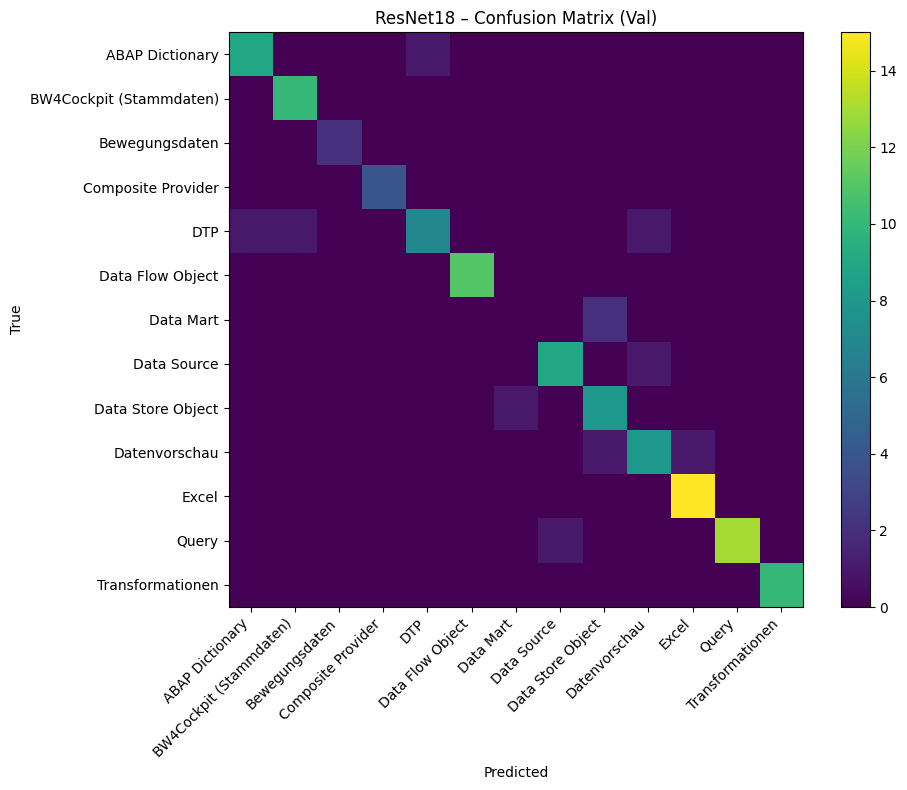

In [36]:
# 10) Bestes ResNet laden + Report + Confusion Matrix (auto GPU->CPU)
watchdog(min_free_mb=1500, auto_set=True, clear=True)

device = TORCH_DEVICE

model = models.resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, n_classes)
model.load_state_dict(torch.load(CKPT, map_location=device))
model.to(device).eval()

y_true, y_pred, acc, dev = eval_model_auto(model, val_loader, min_free_mb=1200)
print("RESNET finetuned acc:", acc, "| device:", dev)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
save_results("ResNet18 finetuned", y_true, y_pred)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("ResNet18 – Confusion Matrix (Val)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()

cuda_cleanup()

---- CUDA status (before) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14019.0, 'allocated_mb': 527.884765625, 'reserved_mb': 848.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
---- CUDA status (after cleanup) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14019.0, 'allocated_mb': 527.884765625, 'reserved_mb': 848.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
[WATCHDOG] Using GPU (free 14019 MB >= 1500 MB).
YOLO finetuned (best.pt) classification_report:
                         precision    recall  f1-score   support

        ABAP Dictionary       1.00      0.90      0.95        10
BW4Cockpit (Stammdaten)       0.91      1.00      0.95        10
         Bewegungsdaten       1.00      1.00      1.00         2
     Composite Provider       0.75      0.75      0.75         4
                    DTP       1.00      0.80      0.89        10
       Data Flow Object       1.00      0.91      0.95        11
              Data Mart       0.00

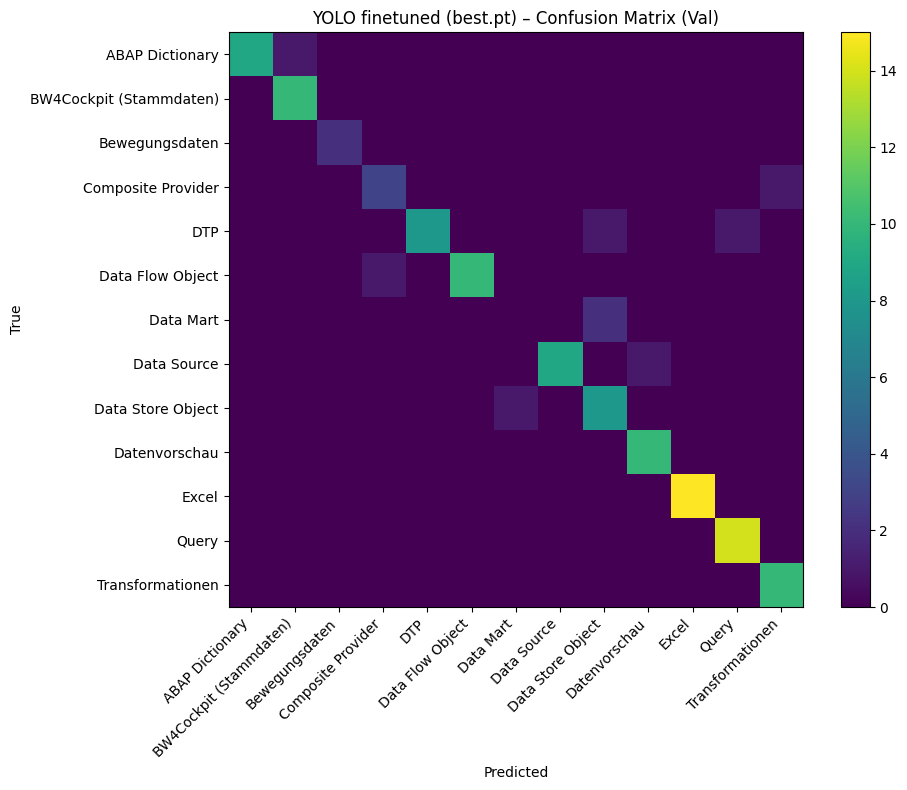

In [37]:
# 11) YOLO finetuned (best.pt = yolo_best) – Report + Confusion Matrix (stabil ohne ultralytics.predict/val)
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

watchdog(min_free_mb=1500, auto_set=True, clear=True)

# Guards: zwingt "best.pt aus Block #6" und ImageFolder Setup aus Block #7
if "yolo_best" not in globals():
    raise RuntimeError("yolo_best ist nicht definiert. Bitte Block #6 (Training + best.pt laden) ausführen.")
if "val_ds" not in globals() or "class_names" not in globals():
    raise RuntimeError("val_ds/class_names fehlen. Bitte Block #7 (ImageFolder Setup) vor Block #11 ausführen.")

def get_yolo_cls_transform(imgsz=224):
    try:
        from ultralytics.data.augment import classify_transforms
        return classify_transforms(imgsz)
    except Exception:
        import torchvision.transforms as T
        mean_ = (0.485, 0.456, 0.406)
        std_  = (0.229, 0.224, 0.225)
        return T.Compose([
            T.Resize((imgsz, imgsz)),
            T.ToTensor(),
            T.Normalize(mean=mean_, std=std_),
        ])

def yolo_logits(yolo_obj, x):
    m = yolo_obj.model
    core = getattr(m, "model", None)
    out = core(x) if core is not None else m(x)
    if isinstance(out, (tuple, list)):
        out = out[0]
    return out

def get_idx_to_name(yolo_obj):
    # robust lesen (YOLO.names kann property sein)
    names = getattr(yolo_obj, "names", None)
    if names is None and hasattr(yolo_obj, "model"):
        names = getattr(yolo_obj.model, "names", None)
    if isinstance(names, dict):
        return {int(k): v for k, v in names.items()}
    if isinstance(names, (list, tuple)):
        return {i: n for i, n in enumerate(names)}
    return None

#WICHTIG: verwenden yolo_best (best.pt)
yolo_eval = yolo_best

yolo_eval_device = TORCH_DEVICE
yolo_use_amp = (yolo_eval_device.type == "cuda")

tf_yolo = get_yolo_cls_transform(224)
idx_to_name = get_idx_to_name(yolo_eval)
class_to_idx = {c: i for i, c in enumerate(class_names)}

yolo_eval.model.to(yolo_eval_device).eval()

val_paths = [Path(p) for p, _ in val_ds.samples]
y_true = np.array([y for _, y in val_ds.samples], dtype=int)

BATCH = 16
y_pred = np.empty(len(val_paths), dtype=int)

with torch.inference_mode():
    for start in range(0, len(val_paths), BATCH):
        chunk = val_paths[start:start + BATCH]
        imgs = [tf_yolo(Image.open(p).convert("RGB")) for p in chunk]
        x = torch.stack(imgs, dim=0).to(yolo_eval_device, non_blocking=yolo_use_amp)

        if yolo_use_amp:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                logits = yolo_logits(yolo_eval, x)
        else:
            logits = yolo_logits(yolo_eval, x)

        top1 = logits.argmax(dim=1).detach().cpu().numpy().astype(int)

        # Mapping: wenn YOLO Namen liefert, mappe über Namen -> class_names Index
        for i, pred_idx in enumerate(top1):
            if idx_to_name is not None:
                pred_name = idx_to_name.get(int(pred_idx), None)
                if pred_name in class_to_idx:
                    y_pred[start + i] = class_to_idx[pred_name]
                else:
                    y_pred[start + i] = int(pred_idx) if int(pred_idx) < len(class_names) else 0
            else:
                y_pred[start + i] = int(pred_idx) if int(pred_idx) < len(class_names) else 0

print("YOLO finetuned (best.pt) classification_report:")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# In RESULTS speichern (setzt voraus, dass save_results in #7 existiert
if "save_results" not in globals():
    if "RESULTS" not in globals():
        RESULTS = {}
    def save_results(name, y_true_, y_pred_):
        RESULTS[name] = {"y_true": np.array(y_true_, copy=True), "y_pred": np.array(y_pred_, copy=True)}

save_results("YOLOv8n-cls finetuned (best.pt)", y_true, y_pred)

cm_yolo = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm_yolo)
plt.title("YOLO finetuned (best.pt) – Confusion Matrix (Val)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()

cuda_cleanup()

[REST] Device: cuda:0
Rest Ungelabelt images: 2827 | folder: ..\Data\Rest Ungelabelt
[REST] Using YOLO (best.pt) for inference.
Saved: ..\Work\rest_ungelabelt_predictions.csv


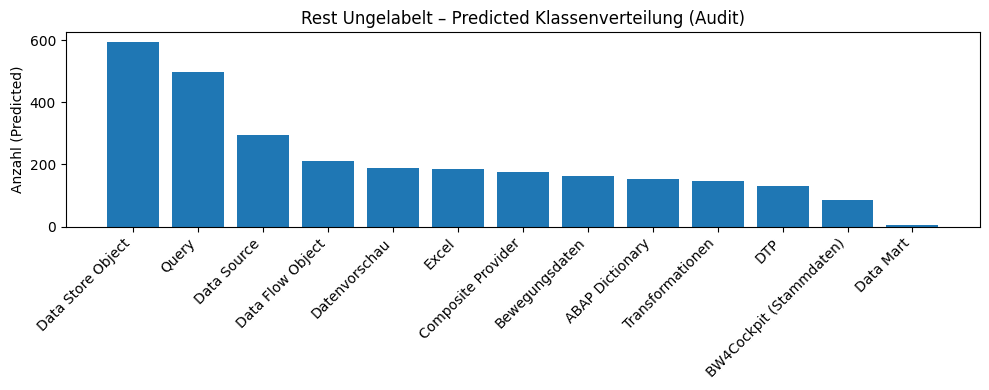

Review copies saved to: ..\Work\review_rest_ungelabelt
Copied per class (high confidence): {}


In [38]:
# 11b) REST UNGELABELT – Inference/Audit (ohne Training/Val)
# Ziel:
# - Rest Ungelabelt einmal mit dem besten Modell (YOLO oder ResNet) durchlaufen
# - CSV erzeugen: file, pred_class, confidence, top5
# - Optional: High-Confidence Samples in Work/review_rest_ungelabelt/{class}/ kopieren


import numpy as np
import pandas as pd
from pathlib import Path
import shutil
import matplotlib.pyplot as plt


# Konfiguration
REST_DIR = UNLABELED_DIR  # ../Data/Rest Ungelabelt
OUT_CSV  = WORK_DIR / "rest_ungelabelt_predictions.csv"
REVIEW_DIR = WORK_DIR / "review_rest_ungelabelt"   # nur Kopien zur Sichtprüfung

CONF_TH = 0.90          # ab dieser Confidence in Review kopieren
DO_COPY_REVIEW = True   # auf False, wenn man nur eine CSV/Plot willst
MAX_PER_CLASS = 200     # optional: pro Klasse maximal so viele Review-Kopien (0 = unendlich)


# Helper
def list_images_flat(folder: Path):
    if not folder.exists():
        return []
    return sorted([p for p in folder.rglob("*") if p.is_file() and is_image(p)])

def softmax_np(x):
    x = x - np.max(x, axis=1, keepdims=True)
    ex = np.exp(x)
    return ex / np.sum(ex, axis=1, keepdims=True)

# YOLO logits fallback
def yolo_logits_fallback(yolo_obj, x):
    m = yolo_obj.model
    core = getattr(m, "model", None)
    out = core(x) if core is not None else m(x)
    if isinstance(out, (tuple, list)):
        out = out[0]
    return out


# Modellwahl: bevorzugt YOLO best.pt, sonst ResNet CKPT

use_yolo = ("yolo_best" in globals())
use_resnet = (("CKPT" in globals()) and Path(CKPT).exists()
              and ("class_names" in globals()) and ("val_tf" in globals()))

if not (use_yolo or use_resnet):
    raise RuntimeError(
        "Kein Modell verfügbar. Führe vorher Block 6 (YOLO Training) und/oder Block 9/10 (ResNet CKPT) aus. "
        "Außerdem müssen class_names und val_tf aus Block 7 existieren."
    )


# Device
dev, use_cuda = ensure_best_device(min_free_mb=1500, prefer_gpu=True, clear=True)
print("[REST] Device:", dev)


# YOLO Inference
def predict_with_yolo(paths):
    yolo_obj = yolo_best
    yolo_obj.model.to(dev).eval()

    # transform (falls Funktion schon existiert, nutze sie; sonst fallback)
    try:
        tf = get_yolo_cls_transform(224)
    except Exception:
        import torchvision.transforms as T
        mean_ = (0.485, 0.456, 0.406)
        std_  = (0.229, 0.224, 0.225)
        tf = T.Compose([T.Resize((224, 224)), T.ToTensor(), T.Normalize(mean=mean_, std=std_)])

    # names mapping robust
    names = getattr(yolo_obj, "names", None)
    if names is None and hasattr(yolo_obj, "model"):
        names = getattr(yolo_obj.model, "names", None)
    if isinstance(names, dict):
        idx_to_name = {int(k): v for k, v in names.items()}
    elif isinstance(names, (list, tuple)):
        idx_to_name = {i: n for i, n in enumerate(names)}
    else:
        idx_to_name = {}

    # logits function: nutze globale yolo_logits, wenn vorhanden, sonst fallback
    logits_fn = globals().get("yolo_logits", None)
    if logits_fn is None:
        logits_fn = yolo_logits_fallback

    BATCH = 16
    rows = []

    with torch.inference_mode():
        for start in range(0, len(paths), BATCH):
            chunk = paths[start:start + BATCH]
            imgs = [tf(Image.open(p).convert("RGB")) for p in chunk]
            x = torch.stack(imgs, dim=0).to(dev, non_blocking=use_cuda)

            if dev.type == "cuda":
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    logits = logits_fn(yolo_obj, x)
            else:
                logits = logits_fn(yolo_obj, x)

            logits_np = logits.detach().cpu().numpy()
            probs = softmax_np(logits_np)

            top1 = probs.argmax(axis=1)
            conf = probs[np.arange(len(top1)), top1]

            top5_idx = np.argsort(-probs, axis=1)[:, :5]
            top5_conf = np.take_along_axis(probs, top5_idx, axis=1)

            for i, p in enumerate(chunk):
                pred_i = int(top1[i])
                pred_name = idx_to_name.get(pred_i, str(pred_i))
                rows.append({
                    "file": str(p),
                    "pred_class": pred_name,
                    "conf": float(conf[i]),
                    "top5_classes": [idx_to_name.get(int(j), str(int(j))) for j in top5_idx[i]],
                    "top5_conf": [float(c) for c in top5_conf[i]],
                })

    return pd.DataFrame(rows)


# ResNet Inference (Fallback)
def predict_with_resnet(paths):
    import torch.nn as nn
    from torchvision import models

    weights_local = models.ResNet18_Weights.IMAGENET1K_V1
    n_classes_local = len(class_names)

    m = models.resnet18(weights=weights_local)
    m.fc = nn.Linear(m.fc.in_features, n_classes_local)
    m.load_state_dict(torch.load(CKPT, map_location=dev))
    m.to(dev).eval()

    BATCH = 32
    rows = []

    with torch.inference_mode():
        for start in range(0, len(paths), BATCH):
            chunk = paths[start:start + BATCH]
            imgs = [val_tf(Image.open(p).convert("RGB")) for p in chunk]  # val_tf aus Block 7
            x = torch.stack(imgs, dim=0).to(dev, non_blocking=use_cuda)

            logits = m(x)
            probs = torch.softmax(logits, dim=1).detach().cpu().numpy()

            top1 = probs.argmax(axis=1)
            conf = probs[np.arange(len(top1)), top1]

            top5_idx = np.argsort(-probs, axis=1)[:, :5]
            top5_conf = np.take_along_axis(probs, top5_idx, axis=1)

            for i, p in enumerate(chunk):
                pred_i = int(top1[i])
                rows.append({
                    "file": str(p),
                    "pred_class": class_names[pred_i],
                    "conf": float(conf[i]),
                    "top5_classes": [class_names[int(j)] for j in top5_idx[i]],
                    "top5_conf": [float(c) for c in top5_conf[i]],
                })

    return pd.DataFrame(rows)


# Run
rest_paths = list_images_flat(REST_DIR)
print("Rest Ungelabelt images:", len(rest_paths), "| folder:", REST_DIR)

if len(rest_paths) == 0:
    raise RuntimeError("REST_DIR ist leer oder enthält keine Bilder.")

if use_yolo:
    print("[REST] Using YOLO (best.pt) for inference.")
    df_rest = predict_with_yolo(rest_paths)
else:
    print("[REST] Using ResNet (CKPT) for inference.")
    df_rest = predict_with_resnet(rest_paths)

df_rest.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)


# Plot: predicted class distribution
pred_counts = df_rest["pred_class"].value_counts()
plt.figure(figsize=(10, 4))
plt.bar(pred_counts.index.astype(str), pred_counts.values)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Anzahl (Predicted)")
plt.title("Rest Ungelabelt – Predicted Klassenverteilung (Audit)")
plt.tight_layout()
plt.show()


# Optional: High-Confidence in Review-Ordner kopieren
if DO_COPY_REVIEW:
    if REVIEW_DIR.exists():
        shutil.rmtree(REVIEW_DIR)
    REVIEW_DIR.mkdir(parents=True, exist_ok=True)

    copied_per_class = {}

    for _, r in df_rest.sort_values("conf", ascending=False).iterrows():
        if float(r["conf"]) < CONF_TH:
            break

        cls = str(r["pred_class"])
        copied_per_class.setdefault(cls, 0)
        if MAX_PER_CLASS > 0 and copied_per_class[cls] >= MAX_PER_CLASS:
            continue

        src = Path(r["file"])
        dst_dir = REVIEW_DIR / cls
        dst_dir.mkdir(parents=True, exist_ok=True)
        dst = dst_dir / src.name

        # kollisionssicher
        if dst.exists():
            dst = dst.with_name(f"{dst.stem}__dup{src.stat().st_size}{dst.suffix}")

        shutil.copy2(src, dst)
        copied_per_class[cls] += 1

    print("Review copies saved to:", REVIEW_DIR)
    print("Copied per class (high confidence):", dict(sorted(copied_per_class.items(), key=lambda x: -x[1])))

cuda_cleanup()

In [39]:
# 12) XAI Dependencies (Captum) + Helpers

try:
    import captum
    print("captum version:", captum.__version__)
except Exception:
    !{sys.executable} -m pip install -U captum
    import captum
    print("captum version:", captum.__version__)


def show_overlay(img_pil, heatmap_2d, title, alpha=0.45, q=0.99):
    hm = np.array(heatmap_2d, dtype=np.float32)
    hm = hm - hm.min()
    vmax = np.quantile(hm, q) if hm.size else 1.0
    if vmax > 0:
        hm = np.clip(hm / vmax, 0, 1)

    img = np.array(img_pil.convert("RGB").resize((hm.shape[1], hm.shape[0])))

    plt.figure(figsize=(7, 5))
    plt.imshow(img)
    plt.imshow(hm, alpha=alpha)
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def attr_to_heatmap(attr_tensor):
    a = attr_tensor.squeeze(0).detach().cpu().numpy()
    hm = np.sum(np.abs(a), axis=0)
    return hm

def pick_val_image(k=0):
    p, y = val_ds.samples[k]
    return Path(p), int(y)

captum version: 0.8.0


File: ..\Work\datasets\base_split\val\ABAP Dictionary\23d334c281e949f79d6701e91745eb96.png


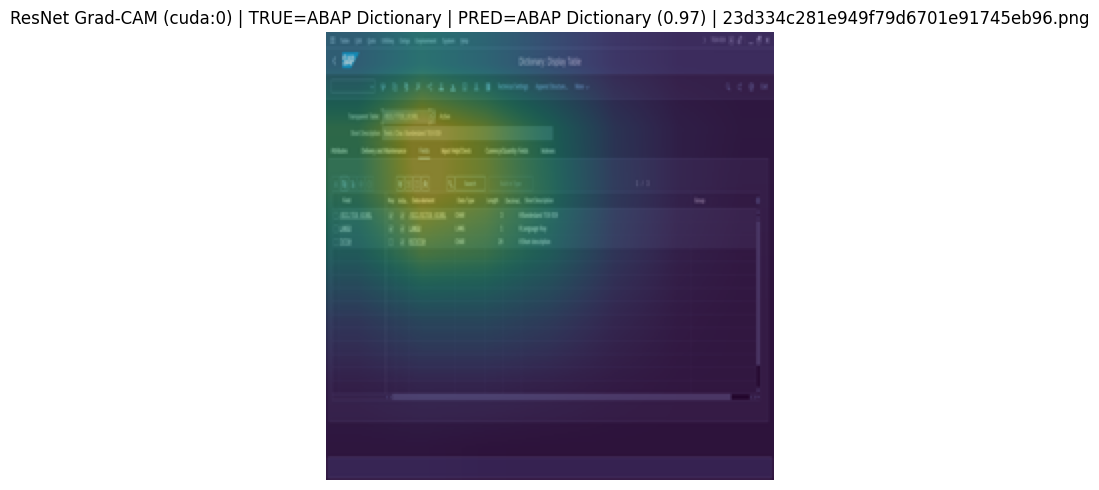

In [40]:
# 13) ResNet XAI: Grad-CAM (auto GPU->CPU)
import torch.nn.functional as F

def gradcam_resnet(model, input_tensor, target_layer):
    model.eval()

    activations = []
    gradients = []

    def fwd_hook(module, inp, out):
        activations.append(out)

    def bwd_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    h1 = target_layer.register_forward_hook(fwd_hook)
    try:
        h2 = target_layer.register_full_backward_hook(bwd_hook)
    except Exception:
        h2 = target_layer.register_backward_hook(bwd_hook)

    input_tensor = input_tensor.requires_grad_(True)
    logits = model(input_tensor)

    pred_idx = int(logits.argmax(dim=1).item())
    probs = torch.softmax(logits.detach(), dim=1)[0]
    pred_conf = float(probs[pred_idx].item())

    model.zero_grad(set_to_none=True)
    score = logits[0, pred_idx]
    score.backward()

    h1.remove()
    h2.remove()

    act = activations[0]
    grad = gradients[0]

    weights = grad.mean(dim=(2, 3), keepdim=True)
    cam = (weights * act).sum(dim=1, keepdim=True)
    cam = torch.relu(cam)

    cam = F.interpolate(cam, size=input_tensor.shape[-2:], mode="bilinear", align_corners=False)
    cam = cam[0, 0].detach().cpu().numpy()

    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()

    return cam, pred_idx, pred_conf

def gradcam_auto(img_path, min_free_mb=1200):
    dev, use_cuda = ensure_best_device(min_free_mb=min_free_mb, prefer_gpu=True, clear=True)
    model.to(dev).eval()

    img_pil = Image.open(img_path).convert("RGB")
    x = val_tf(img_pil).unsqueeze(0).to(dev, non_blocking=use_cuda)

    cam, pred_idx, pred_conf = gradcam_resnet(model, x, target_layer=model.layer4[-1])
    return img_pil, cam, pred_idx, pred_conf, dev

img_path, true_idx = pick_val_image(0)
img_pil, cam, pred_idx, pred_conf, dev = gradcam_auto(img_path, min_free_mb=1200)
title = f"ResNet Grad-CAM ({dev}) | TRUE={class_names[true_idx]} | PRED={class_names[pred_idx]} ({pred_conf:.2f}) | {img_path.name}"
print("File:", img_path)
show_overlay(img_pil, cam, title=title, alpha=0.45)

cuda_cleanup()

File: ..\Work\datasets\base_split\val\ABAP Dictionary\23d334c281e949f79d6701e91745eb96.png


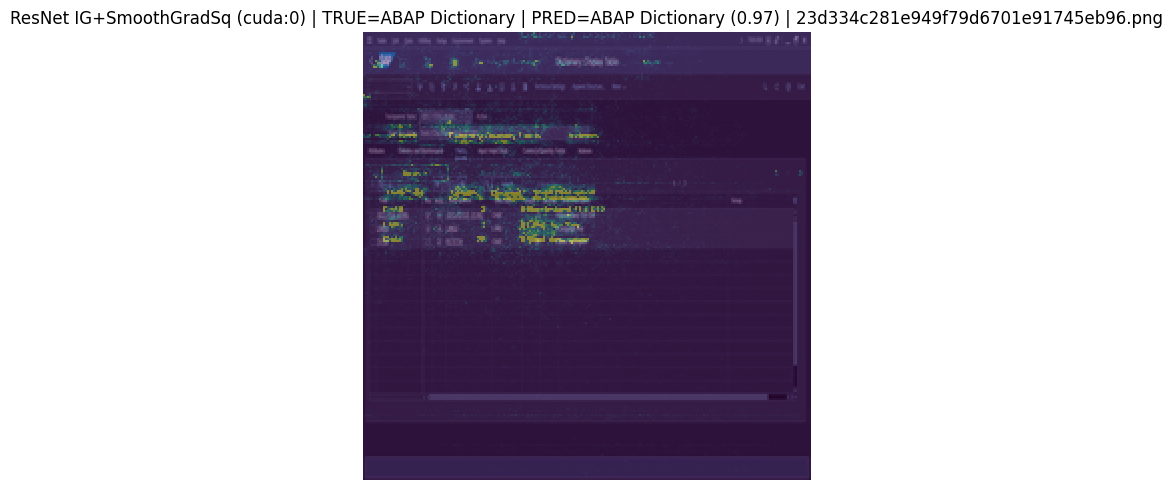

In [41]:
# 14) ResNet XAI: Integrated Gradients + SmoothGradSq (auto GPU->CPU)
from PIL import Image, ImageFilter
from captum.attr import IntegratedGradients, NoiseTunnel

def ig_resnet_smooth_auto(
    img_path,
    min_free_mb=2500,
    n_steps_gpu=24, nt_samples_gpu=8,
    n_steps_cpu=48, nt_samples_cpu=12,
    stdevs=0.15,
    use_blur_baseline=True
):
    dev, use_cuda = ensure_best_device(min_free_mb=min_free_mb, prefer_gpu=True, clear=True)
    if dev.type == "cuda":
        n_steps, nt_samples = n_steps_gpu, nt_samples_gpu
    else:
        n_steps, nt_samples = n_steps_cpu, nt_samples_cpu

    model.to(dev).eval()
    img_pil = Image.open(img_path).convert("RGB")

    x = val_tf(img_pil).unsqueeze(0).to(dev)
    x = x.clone().detach().requires_grad_(True)

    baselines = None
    if use_blur_baseline:
        blur = img_pil.filter(ImageFilter.GaussianBlur(radius=8))
        baselines = val_tf(blur).unsqueeze(0).to(dev)

    def forward_fn(t):
        return model(t)

    with torch.enable_grad():
        logits = forward_fn(x)
        pred_idx = int(logits.argmax(dim=1).item())
        probs = torch.softmax(logits.detach(), dim=1)[0].detach().cpu().numpy()
        conf = float(probs[pred_idx])

        ig = IntegratedGradients(forward_fn)
        nt = NoiseTunnel(ig)

        attr = nt.attribute(
            x, baselines=baselines, target=pred_idx,
            n_steps=n_steps, nt_type="smoothgrad_sq",
            nt_samples=nt_samples, stdevs=stdevs
        )

    return img_pil, attr, pred_idx, conf, dev

img_path, true_idx = pick_val_image(0)
img_pil, attr, pred_idx, conf, dev = ig_resnet_smooth_auto(
    img_path,
    min_free_mb=2500,
    n_steps_gpu=24,
    nt_samples_gpu=8
)
hm = attr_to_heatmap(attr)
title = f"ResNet IG+SmoothGradSq ({dev}) | TRUE={class_names[true_idx]} | PRED={class_names[pred_idx]} ({conf:.2f}) | {img_path.name}"
print("File:", img_path)
show_overlay(img_pil, hm, title=title, alpha=0.45)

cuda_cleanup()

Val acc (CPU eval): 0.905982905982906
Misclassified: 11
File: ..\Work\datasets\base_split\val\ABAP Dictionary\6b30182c6cec40299b84d7c8196271bf.jpeg


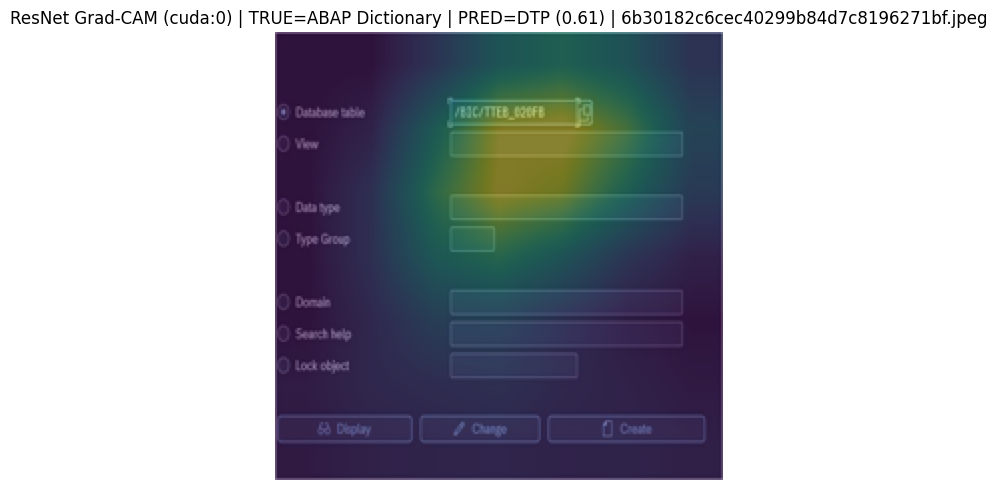

File: ..\Work\datasets\base_split\val\DTP\a824d64ca35f446f9f367421ffe44154.png


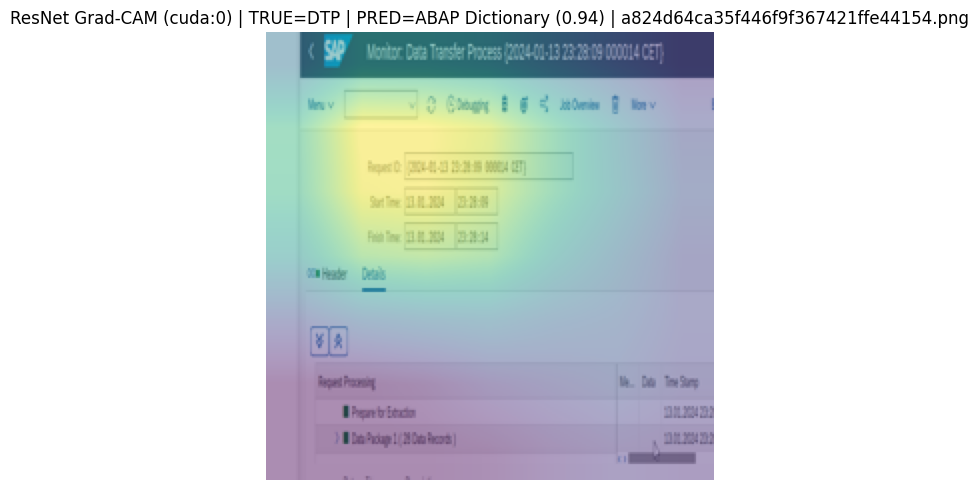

File: ..\Work\datasets\base_split\val\DTP\acd72595643c4028bed55793e1360ae0.png


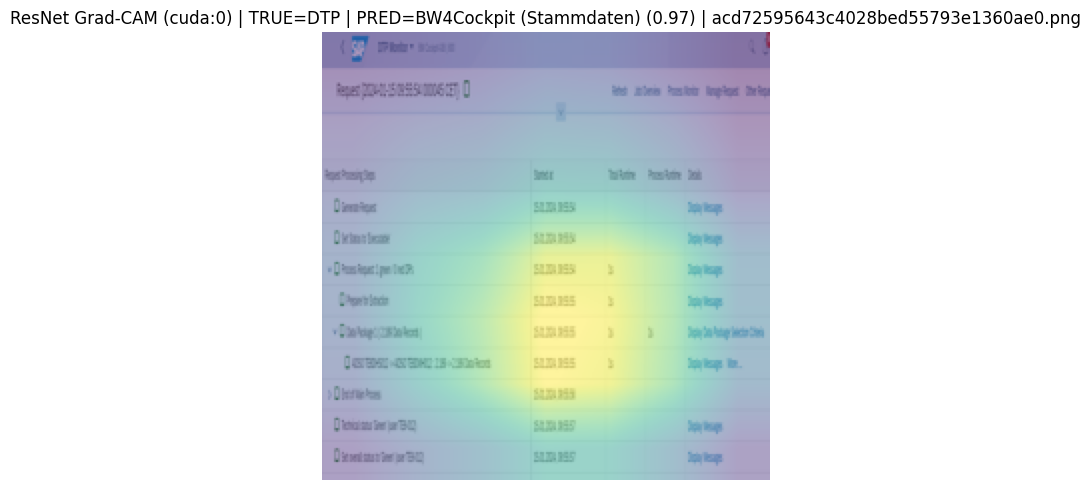

File: ..\Work\datasets\base_split\val\DTP\image_page24_2.png


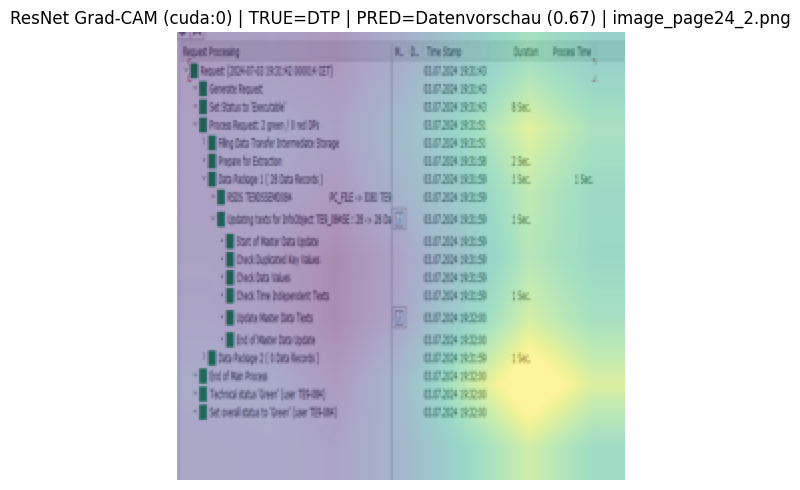

File: ..\Work\datasets\base_split\val\Data Mart\3e6f14c289b643268e7420c16526f0ee.png


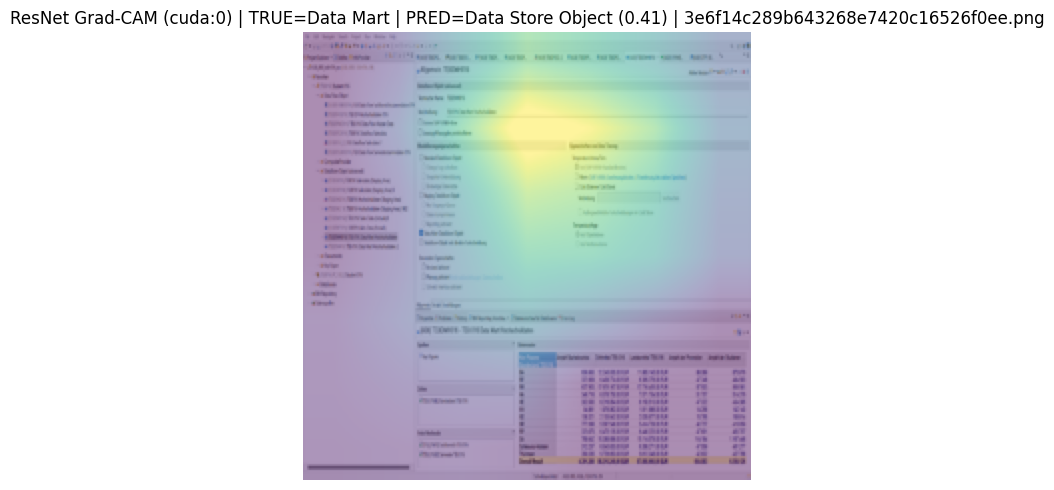

In [42]:
# 15) ResNet: Fehlklassifikationen finden + XAI (Grad-CAM) anzeigen
val_loader_cpu = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=0, pin_memory=False)

def eval_model_cpu(model, loader):
    model_cpu = model.to("cpu").eval()
    y_true, y_pred = [], []
    with torch.inference_mode():
        for x, y in loader:
            logits = model_cpu(x)
            pred = logits.argmax(dim=1).numpy()
            y_true.extend(y.numpy())
            y_pred.extend(pred)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = float((y_true == y_pred).mean())
    return y_true, y_pred, acc

y_true, y_pred, acc = eval_model_cpu(model, val_loader_cpu)
print("Val acc (CPU eval):", acc)

mis_idx = np.where(y_true != y_pred)[0]
print("Misclassified:", len(mis_idx))

N_SHOW = 5
for k in mis_idx[:N_SHOW]:
    img_path = Path(val_ds.samples[k][0])
    true_idx = int(y_true[k])
    pred_idx_expected = int(y_pred[k])

    img_pil, cam, pred_idx_cam, pconf, dev = gradcam_auto(img_path, min_free_mb=1200)
    title = (
        f"ResNet Grad-CAM ({dev}) | TRUE={class_names[true_idx]} | "
        f"PRED={class_names[pred_idx_expected]} ({pconf:.2f}) | {img_path.name}"
    )
    print("File:", img_path)
    show_overlay(img_pil, cam, title=title, alpha=0.45)

cuda_cleanup()

---- CUDA status (before) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14019.0, 'allocated_mb': 579.53515625, 'reserved_mb': 848.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
---- CUDA status (after cleanup) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14019.0, 'allocated_mb': 579.53515625, 'reserved_mb': 848.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
[WATCHDOG] Using GPU (free 14019 MB >= 2500 MB).
File: ..\Work\datasets\base_split\val\ABAP Dictionary\23d334c281e949f79d6701e91745eb96.png


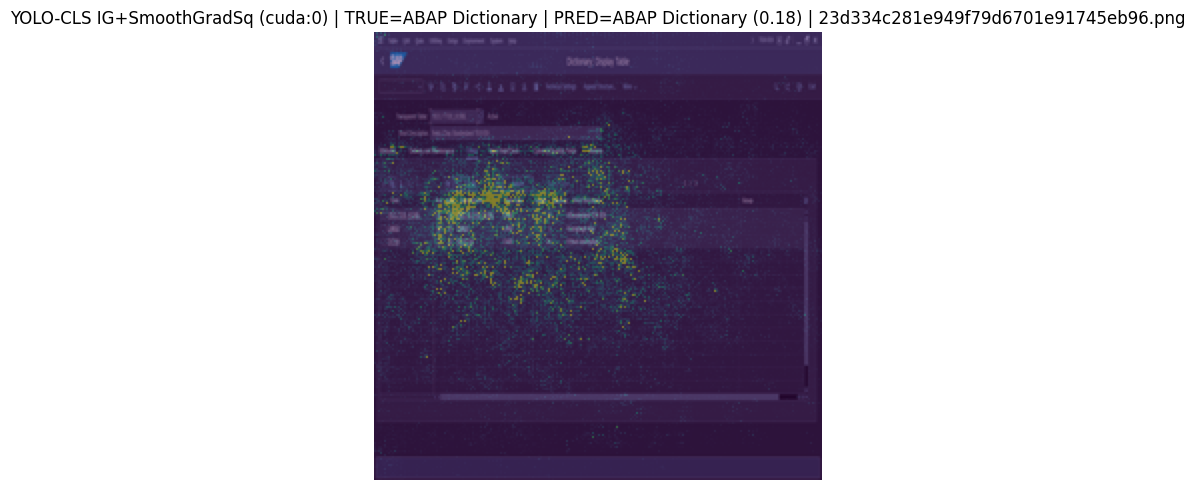

In [43]:
# 16) YOLO-CLS XAI: Integrated Gradients (SmoothGradSq) auf yolo_best (auto GPU->CPU)

watchdog(min_free_mb=2500, auto_set=True, clear=True)

# Sicherstellen, dass best.pt bereits geladen wurde
if "yolo_best" not in globals():
    raise RuntimeError("yolo_best ist nicht definiert. Bitte erst Block #6 (Training + best.pt laden) ausführen.")

yolo_xai = yolo_best

# Modell-Extraktion
base_model = getattr(yolo_xai, "model", None)
seq = getattr(base_model, "model", None) if base_model is not None else None
if seq is None:
    if base_model is None:
        raise RuntimeError("Konnte YOLO Modell nicht extrahieren (yolo_xai.model fehlt).")
    seq = base_model

names = getattr(yolo_xai, "names", None)
if names is None and hasattr(yolo_xai, "model"):
    names = getattr(yolo_xai.model, "names", None)

if isinstance(names, dict):
    idx_to_name = {int(k): v for k, v in names.items()}
elif isinstance(names, (list, tuple)):
    idx_to_name = {i: n for i, n in enumerate(names)}
else:
    idx_to_name = {}

def get_yolo_cls_transform(imgsz=224):
    try:
        from ultralytics.data.augment import classify_transforms
        return classify_transforms(imgsz)
    except Exception:
        import torchvision.transforms as T
        mean = (0.485, 0.456, 0.406)
        std  = (0.229, 0.224, 0.225)
        return T.Compose([
            T.Resize((imgsz, imgsz)),
            T.ToTensor(),
            T.Normalize(mean=mean, std=std),
        ])

tf_yolo = get_yolo_cls_transform(224)

def yolo_forward(x):
    out = seq(x)
    if isinstance(out, (tuple, list)):
        out = out[0]
    return out


def ig_yolo_smooth_auto(
    img_path,
    min_free_mb=2500,
    n_steps_gpu=24, nt_samples_gpu=8,
    n_steps_cpu=48, nt_samples_cpu=12,
    stdevs=0.15,
    use_blur_baseline=True
):
    dev, use_cuda = ensure_best_device(min_free_mb=min_free_mb, prefer_gpu=True, clear=True)

    if dev.type == "cuda":
        n_steps, nt_samples = n_steps_gpu, nt_samples_gpu
    else:
        n_steps, nt_samples = n_steps_cpu, nt_samples_cpu

    seq.to(dev).eval()

    img_pil = Image.open(img_path).convert("RGB")
    x = tf_yolo(img_pil).unsqueeze(0).to(dev, non_blocking=use_cuda)
    x = x.clone().detach().requires_grad_(True)

    baselines = None
    if use_blur_baseline:
        blur = img_pil.filter(ImageFilter.GaussianBlur(radius=8))
        baselines = tf_yolo(blur).unsqueeze(0).to(dev, non_blocking=use_cuda)

    with torch.enable_grad():
        logits = yolo_forward(x)
        pred_idx = int(logits.argmax(dim=1).item())
        probs = torch.softmax(logits.detach(), dim=1)[0].detach().cpu().numpy()
        conf = float(probs[pred_idx])

        ig = IntegratedGradients(yolo_forward)
        nt = NoiseTunnel(ig)

        attr = nt.attribute(
            x,
            baselines=baselines,
            target=pred_idx,
            n_steps=n_steps,
            nt_type="smoothgrad_sq",
            nt_samples=nt_samples,
            stdevs=stdevs
        )

    return img_pil, attr, pred_idx, conf, probs, dev

# Beispielbild aus Val
img_path = Path(val_ds.samples[0][0])
true_idx = int(val_ds.samples[0][1])

img_pil, attr, pred_idx, conf, probs, dev_used = ig_yolo_smooth_auto(
    img_path,
    min_free_mb=2500,
    n_steps_gpu=24,
    nt_samples_gpu=8,
    stdevs=0.15,
    use_blur_baseline=True
)

hm = attr_to_heatmap(attr)
pred_name = idx_to_name.get(pred_idx, str(pred_idx))
title = f"YOLO-CLS IG+SmoothGradSq ({dev_used}) | TRUE={class_names[true_idx]} | PRED={pred_name} ({conf:.2f}) | {img_path.name}"
print("File:", img_path)
show_overlay(img_pil, hm, title=title, alpha=0.45)

cuda_cleanup()

---- CUDA status (before) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14021.0, 'allocated_mb': 572.29833984375, 'reserved_mb': 846.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
---- CUDA status (after cleanup) ----
{'cuda': True, 'total_mb': 16302.5625, 'free_mb': 14021.0, 'allocated_mb': 572.29833984375, 'reserved_mb': 846.0, 'device': 'NVIDIA GeForce RTX 5080', 'capability': (12, 0)}
[WATCHDOG] Using GPU (free 14021 MB >= 1500 MB).
YOLO (best.pt) val acc: 0.9230769230769231 | device: cuda:0
YOLO Misclassified: 9
File: ..\Work\datasets\base_split\val\ABAP Dictionary\6b30182c6cec40299b84d7c8196271bf.jpeg


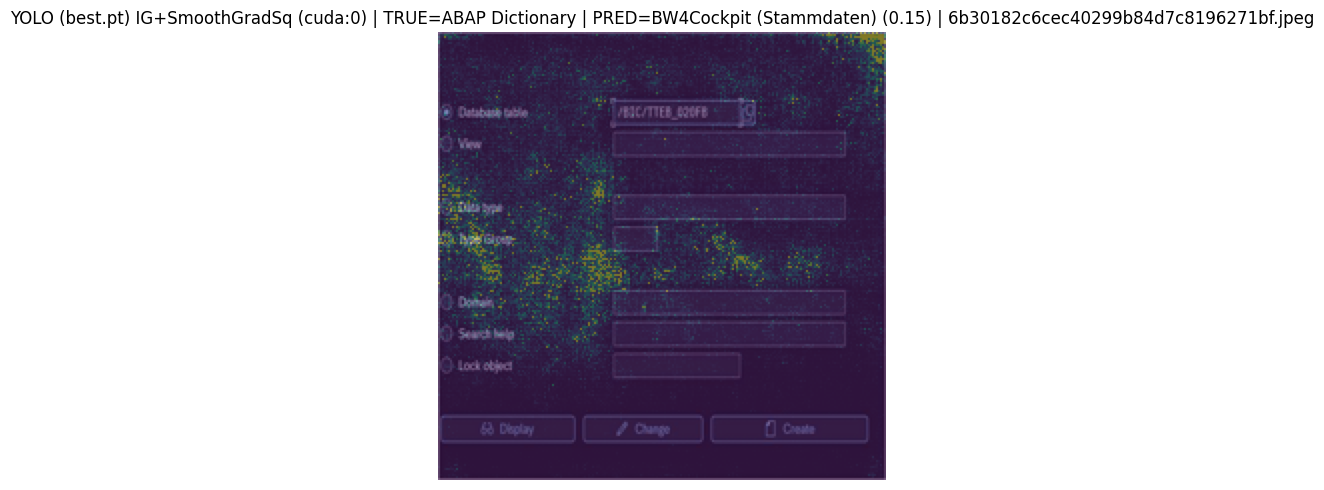

File: ..\Work\datasets\base_split\val\Composite Provider\2f4ff7ee3dd64caab805b62cd411f19e.png


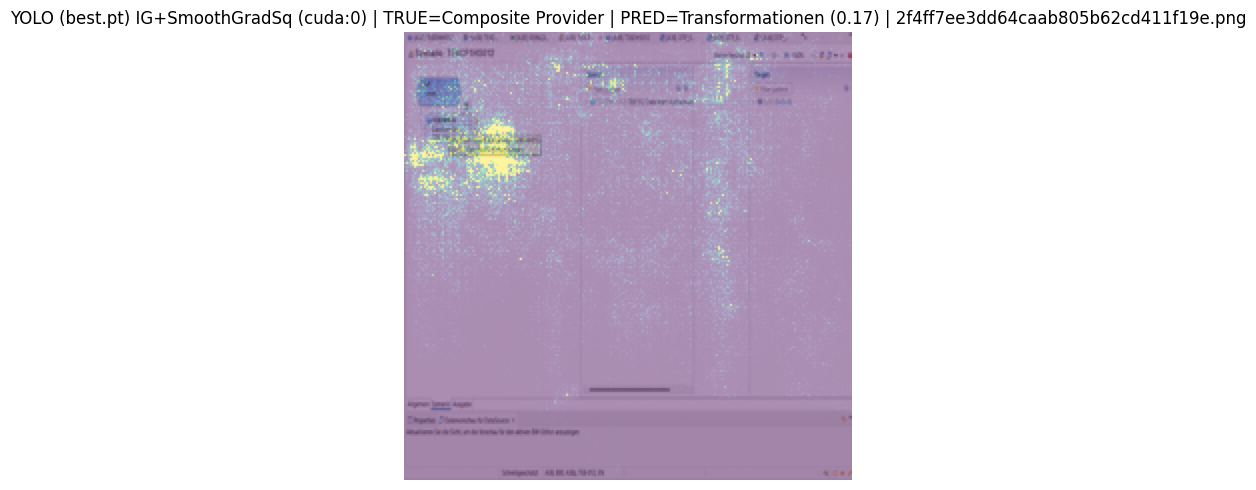

File: ..\Work\datasets\base_split\val\DTP\acd72595643c4028bed55793e1360ae0.png


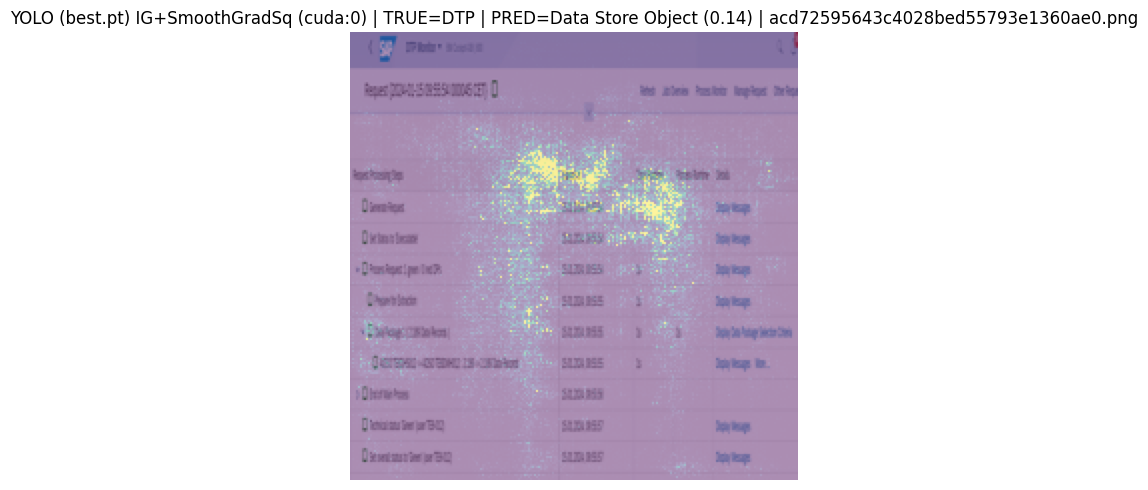

File: ..\Work\datasets\base_split\val\DTP\image_page24_2.png


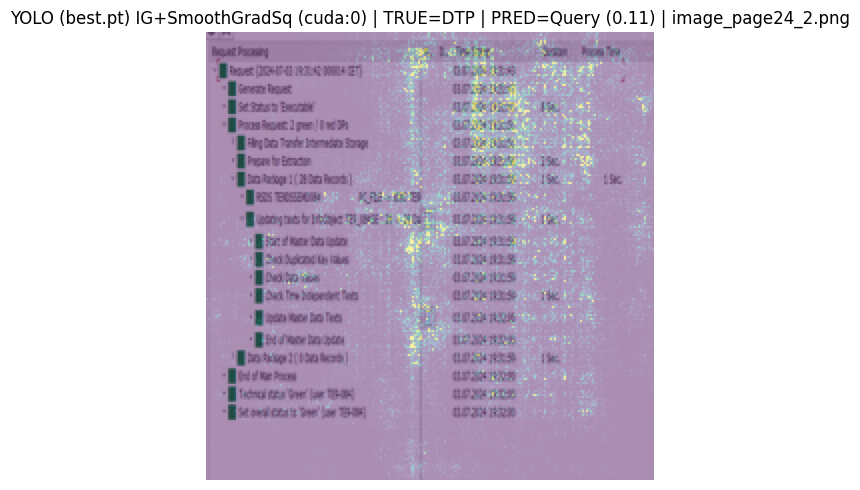

File: ..\Work\datasets\base_split\val\Data Flow Object\9cf15a2bd62c48c09fb44cbd9a39058d.png


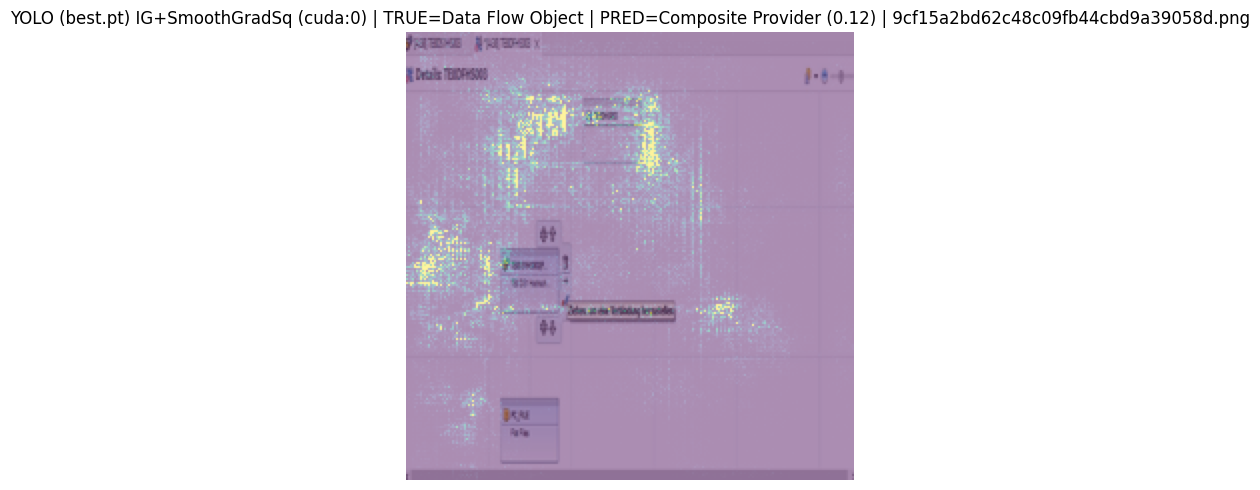

In [44]:
# 17) YOLO (best.pt = yolo_best): Fehlklassifikationen finden + XAI (IG+SmoothGradSq) anzeigen

import numpy as np
from pathlib import Path
from PIL import Image, ImageFilter
import torch
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients, NoiseTunnel

watchdog(min_free_mb=1500, auto_set=True, clear=True)

# Guards: zwingt "best.pt und ImageFolder Setup
if "yolo_best" not in globals():
    raise RuntimeError("yolo_best ist nicht definiert. Bitte Block #6 (Training + best.pt laden) ausführen.")
if "val_ds" not in globals() or "class_names" not in globals():
    raise RuntimeError("val_ds/class_names fehlen. Bitte Block #7 (ImageFolder Setup) vor Block #17 ausführen.")
if "show_overlay" not in globals() or "attr_to_heatmap" not in globals():
    raise RuntimeError("XAI-Helper fehlen. Bitte Block #12 (Captum + Helpers) vor Block #17 ausführen.")

def get_yolo_cls_transform(imgsz=224):
    try:
        from ultralytics.data.augment import classify_transforms
        return classify_transforms(imgsz)
    except Exception:
        import torchvision.transforms as T
        mean_ = (0.485, 0.456, 0.406)
        std_  = (0.229, 0.224, 0.225)
        return T.Compose([
            T.Resize((imgsz, imgsz)),
            T.ToTensor(),
            T.Normalize(mean=mean_, std=std_),
        ])

def get_idx_to_name(yolo_obj):
    names = getattr(yolo_obj, "names", None)
    if names is None and hasattr(yolo_obj, "model"):
        names = getattr(yolo_obj.model, "names", None)
    if isinstance(names, dict):
        return {int(k): v for k, v in names.items()}
    if isinstance(names, (list, tuple)):
        return {i: n for i, n in enumerate(names)}
    return {}

yolo_xai = yolo_best

# Modell-Extraktion
base_model = getattr(yolo_xai, "model", None)
seq = getattr(base_model, "model", None) if base_model is not None else None
if seq is None:
    if base_model is None:
        raise RuntimeError("Konnte YOLO Modell nicht extrahieren (yolo_best.model fehlt).")
    seq = base_model

def yolo_forward(x):
    out = seq(x)
    if isinstance(out, (tuple, list)):
        out = out[0]
    return out


# A) Fehlklassifikationen (Prediction mit yolo_best)
tf_yolo = get_yolo_cls_transform(224)
idx_to_name = get_idx_to_name(yolo_xai)
class_to_idx = {c: i for i, c in enumerate(class_names)}

val_paths = [Path(p) for p, _ in val_ds.samples]
y_true = np.array([y for _, y in val_ds.samples], dtype=int)

dev, use_cuda = ensure_best_device(min_free_mb=1500, prefer_gpu=True, clear=True)
seq.to(dev).eval()

BATCH = 16
y_pred = np.empty(len(val_paths), dtype=int)

with torch.inference_mode():
    for start in range(0, len(val_paths), BATCH):
        chunk = val_paths[start:start + BATCH]
        imgs = [tf_yolo(Image.open(p).convert("RGB")) for p in chunk]
        x = torch.stack(imgs, dim=0).to(dev, non_blocking=use_cuda)

        if dev.type == "cuda":
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                logits = yolo_forward(x)
        else:
            logits = yolo_forward(x)

        top1 = logits.argmax(dim=1).detach().cpu().numpy().astype(int)

        for i, pred_idx in enumerate(top1):
            pred_name = idx_to_name.get(int(pred_idx), None)
            if pred_name in class_to_idx:
                y_pred[start + i] = class_to_idx[pred_name]
            else:
                y_pred[start + i] = int(pred_idx) if int(pred_idx) < len(class_names) else 0

acc_yolo = float((y_true == y_pred).mean())
print("YOLO (best.pt) val acc:", acc_yolo, "| device:", dev)

mis_idx = np.where(y_true != y_pred)[0]
print("YOLO Misclassified:", len(mis_idx))


# B) XAI: Integrated Gradients + SmoothGradSq auf denselben yolo_best/seq
def ig_yolo_smooth(img_path, min_free_mb=2500, stdevs=0.15, n_steps_gpu=24, nt_samples_gpu=8,
                   n_steps_cpu=48, nt_samples_cpu=12, use_blur_baseline=True):
    dev2, use_cuda2 = ensure_best_device(min_free_mb=min_free_mb, prefer_gpu=True, clear=True)

    if dev2.type == "cuda":
        n_steps, nt_samples = n_steps_gpu, nt_samples_gpu
    else:
        n_steps, nt_samples = n_steps_cpu, nt_samples_cpu

    seq.to(dev2).eval()

    img_pil = Image.open(img_path).convert("RGB")
    x = tf_yolo(img_pil).unsqueeze(0).to(dev2, non_blocking=use_cuda2)
    x = x.clone().detach().requires_grad_(True)

    baselines = None
    if use_blur_baseline:
        blur = img_pil.filter(ImageFilter.GaussianBlur(radius=8))
        baselines = tf_yolo(blur).unsqueeze(0).to(dev2, non_blocking=use_cuda2)

    with torch.enable_grad():
        logits = yolo_forward(x)
        pred_idx = int(logits.argmax(dim=1).item())
        probs = torch.softmax(logits.detach(), dim=1)[0].detach().cpu().numpy()
        conf = float(probs[pred_idx])

        ig = IntegratedGradients(yolo_forward)
        nt = NoiseTunnel(ig)

        attr = nt.attribute(
            x, baselines=baselines, target=pred_idx,
            n_steps=n_steps, nt_type="smoothgrad_sq",
            nt_samples=nt_samples, stdevs=stdevs
        )

    return img_pil, attr, pred_idx, conf, dev2

# Zeigt ein paar Fehlklassifikationen
N_SHOW = 5
for k in mis_idx[:N_SHOW]:
    img_path = val_paths[int(k)]
    true_idx = int(y_true[int(k)])
    pred_idx_expected = int(y_pred[int(k)])  # unser gemappter Klassenindex

    img_pil, attr, pred_idx_logits, conf, dev_used = ig_yolo_smooth(img_path, min_free_mb=2500)
    hm = attr_to_heatmap(attr)

    # Anzeige
    title = (
        f"YOLO (best.pt) IG+SmoothGradSq ({dev_used}) | TRUE={class_names[true_idx]} | "
        f"PRED={class_names[pred_idx_expected]} ({conf:.2f}) | {img_path.name}"
    )
    print("File:", img_path)
    show_overlay(img_pil, hm, title=title, alpha=0.45)

cuda_cleanup()

In [45]:
# 18) Modellvergleichstabelle (Accuracy / F1 Macro / F1 Weighted)
def metrics_row(name, y_true, y_pred):
    return {
        "model": name,
        "acc": float(accuracy_score(y_true, y_pred)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "n": int(len(y_true)),
    }

if not RESULTS:
    raise RuntimeError("RESULTS ist leer. Prüfe, ob save_results(...) nach den Reports ausgeführt wurde.")

rows = [metrics_row(name, d["y_true"], d["y_pred"]) for name, d in RESULTS.items()]
df_cmp = pd.DataFrame(rows).sort_values(["f1_macro", "acc"], ascending=False)

display(df_cmp)

OUT_CSV = WORK_DIR / "model_comparison.csv"
df_cmp.to_csv(OUT_CSV, index=False)
print("Saved:", OUT_CSV)

,model,acc,f1_macro,f1_weighted,n
4,YOLOv8n-cls finetuned (best.pt),0.923077,0.854513,0.919668,117
3,ResNet18 finetuned,0.905983,0.850836,0.901703,117
0,YOLOv8n-cls baseline (random head),0.085470,0.031859,0.037387,117
1,ResNet18 random,0.042735,0.016662,0.015610,117
2,ResNet18 pretrained (no finetune),0.085470,0.013038,0.014486,117


Saved: ..\Work\model_comparison.csv
